## Step 1: Imports and setup

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity

# One-time NLTK downloads (safe to re-run)
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

## Step 2: Configuration

In [2]:
DOCS_DIR = "documents"          # folder containing the .txt corpus
OUTPUT_DIR = "output_assets"    # where charts / tables get saved
STOPWORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Step 3: Load the documents

In [3]:
def load_documents(folder):
    """Read every .txt file in `folder` and return {filename: raw_text}."""
    doc_paths = sorted(glob.glob(os.path.join(folder, "*.txt")))
    if not doc_paths:
        raise FileNotFoundError(f"No .txt files found in '{folder}'")
    documents = {}
    for path in doc_paths:
        name = os.path.basename(path)
        with open(path, "r", encoding="utf-8") as f:
            documents[name] = f.read()
    return documents

documents = load_documents(DOCS_DIR)
doc_names = list(documents.keys())

print(f"Loaded {len(doc_names)} documents:")
for name in doc_names:
    print(f"  - {name} ({len(documents[name].split())} words)")

Loaded 9 documents:
  - doc1_ai_regulation.txt (286 words)
  - doc2_agentic_ai_governance.txt (268 words)
  - doc3_nasa_artemis.txt (256 words)
  - doc4_space_exploration_outlook.txt (263 words)
  - doc5_cop31_climate.txt (261 words)
  - doc6_renewable_energy.txt (262 words)
  - doc7_football_transfers.txt (248 words)
  - doc8_winter_olympics.txt (242 words)
  - doc9_ebola_outbreak.txt (267 words)


## Step 4: Pre-processing (clean, tokenize, remove stopwords, stem)

In [4]:
def preprocess(text):

    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)        # keep letters only
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    tokens = [STEMMER.stem(t) for t in tokens]
    return tokens

token_lists = [preprocess(documents[name]) for name in doc_names]

for name, tokens in zip(doc_names, token_lists):
    print(f"  - {name}: {len(tokens)} tokens after cleaning (sample: {tokens[:8]})")

  - doc1_ai_regulation.txt: 185 tokens after cleaning (sample: ['titl', 'global', 'regul', 'landscap', 'sourc', 'refer', 'reproduc', 'blog'])
  - doc2_agentic_ai_governance.txt: 165 tokens after cleaning (sample: ['titl', 'agent', 'enter', 'regul', 'industri', 'test', 'govern', 'framework'])
  - doc3_nasa_artemis.txt: 167 tokens after cleaning (sample: ['titl', 'artemi', 'carri', 'astronaut', 'around', 'moon', 'first', 'time'])
  - doc4_space_exploration_outlook.txt: 180 tokens after cleaning (sample: ['titl', 'mark', 'busi', 'year', 'space', 'explor', 'beyond', 'moon'])
  - doc5_cop31_climate.txt: 164 tokens after cleaning (sample: ['titl', 'cop', 'set', 'conven', 'turkey', 'amid', 'shift', 'global'])
  - doc6_renewable_energy.txt: 173 tokens after cleaning (sample: ['titl', 'solar', 'wind', 'batteri', 'storag', 'set', 'domin', 'new'])
  - doc7_football_transfers.txt: 172 tokens after cleaning (sample: ['titl', 'post', 'world', 'cup', 'transfer', 'window', 'becom', 'expens'])
  - doc8

## Step 5: Build the shared vocabulary

In [5]:
def build_vocabulary(token_lists):
    return sorted(set(t for tokens in token_lists for t in tokens))

vocab = build_vocabulary(token_lists)
print(f"Vocabulary size: {len(vocab)} unique terms")

Vocabulary size: 795 unique terms


## Step 6: Term Frequence (TF) matrix

In [6]:
def compute_tf_matrix(token_lists, vocab):
    vocab_index = {term: i for i, term in enumerate(vocab)}
    tf = np.zeros((len(token_lists), len(vocab)))
    for doc_idx, tokens in enumerate(token_lists):
        doc_len = len(tokens) if tokens else 1
        counts = {}
        for t in tokens:
            counts[t] = counts.get(t, 0) + 1
        for term, count in counts.items():
            tf[doc_idx, vocab_index[term]] = count / doc_len
    return tf

tf_matrix = compute_tf_matrix(token_lists, vocab)
print("TF matrix shape:", tf_matrix.shape)

TF matrix shape: (9, 795)


## Step 7: Inverse Document Frequency (IDF) vector

In [7]:
def compute_idf_vector(token_lists, vocab):
    """
    IDF(t) = ln( (1 + N) / (1 + df(t)) ) + 1   (smoothed, sklearn convention)
    N = number of documents, df(t) = number of documents containing t.
    """
    N = len(token_lists)
    vocab_index = {term: i for i, term in enumerate(vocab)}
    df = np.zeros(len(vocab))
    for tokens in token_lists:
        for term in set(tokens):
            df[vocab_index[term]] += 1
    idf = np.log((1 + N) / (1 + df)) + 1
    return idf

idf_vector = compute_idf_vector(token_lists, vocab)
print("IDF vector shape:", idf_vector.shape)

IDF vector shape: (795,)


## Step 8: TF-IDF matrix (weighting + normalization)

In [8]:
def compute_tfidf_matrix(tf_matrix, idf_vector):
    """
    TF-IDF(t, d) = TF(t, d) * IDF(t), then L2-normalise every document row
    so the cosine similarity below reduces to a plain dot product.
    """
    tfidf = tf_matrix * idf_vector
    norms = np.linalg.norm(tfidf, axis=1, keepdims=True)
    norms[norms == 0] = 1
    return tfidf / norms

tfidf_matrix = compute_tfidf_matrix(tf_matrix, idf_vector)
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9, 795)


## Step 9: Cosine similarity matrix (the core Vector Space Model similarity score)

In [9]:
def cosine_similarity_matrix(vectors):
    """cos_sim(A, B) = A . B   (valid since vectors are already unit length)."""
    return vectors @ vectors.T

sim_matrix = cosine_similarity_matrix(tfidf_matrix)
sim_df = pd.DataFrame(sim_matrix, index=doc_names, columns=doc_names)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
print(sim_df.round(3))

                                    doc1_ai_regulation.txt  doc2_agentic_ai_governance.txt  doc3_nasa_artemis.txt  doc4_space_exploration_outlook.txt  \
doc1_ai_regulation.txt                               1.000                           0.252                  0.023                               0.034   
doc2_agentic_ai_governance.txt                       0.252                           1.000                  0.071                               0.044   
doc3_nasa_artemis.txt                                0.023                           0.071                  1.000                               0.432   
doc4_space_exploration_outlook.txt                   0.034                           0.044                  0.432                               1.000   
doc5_cop31_climate.txt                               0.070                           0.048                  0.029                               0.030   
doc6_renewable_energy.txt                            0.090                        

## Step 10: Cross-check against scikit learn (sanity test)

In [10]:
preprocessed_strings = [" ".join(tokens) for tokens in token_lists]
sk_vectorizer = TfidfVectorizer()
sk_tfidf = sk_vectorizer.fit_transform(preprocessed_strings)
sk_sim = sk_cosine_similarity(sk_tfidf)
sk_sim_df = pd.DataFrame(sk_sim, index=doc_names, columns=doc_names)

max_abs_diff = np.max(np.abs(sim_df.values - sk_sim_df.values))
print(f"Max absolute difference vs scikit-learn: {max_abs_diff:.4f}")

Max absolute difference vs scikit-learn: 0.0000


## Step 11: Most similar/least similar document pairs

In [11]:
pairs = []
n = len(doc_names)
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((doc_names[i], doc_names[j], sim_matrix[i, j]))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("Top 5 MOST similar document pairs:")
for a, b, score in pairs_sorted[:5]:
    print(f"  {a}  <->  {b}   similarity = {score:.3f}")

print("\nTop 5 LEAST similar document pairs:")
for a, b, score in pairs_sorted[-5:]:
    print(f"  {a}  <->  {b}   similarity = {score:.3f}")

Top 5 MOST similar document pairs:
  doc3_nasa_artemis.txt  <->  doc4_space_exploration_outlook.txt   similarity = 0.432
  doc1_ai_regulation.txt  <->  doc2_agentic_ai_governance.txt   similarity = 0.252
  doc4_space_exploration_outlook.txt  <->  doc6_renewable_energy.txt   similarity = 0.100
  doc2_agentic_ai_governance.txt  <->  doc6_renewable_energy.txt   similarity = 0.093
  doc7_football_transfers.txt  <->  doc8_winter_olympics.txt   similarity = 0.091

Top 5 LEAST similar document pairs:
  doc3_nasa_artemis.txt  <->  doc7_football_transfers.txt   similarity = 0.026
  doc2_agentic_ai_governance.txt  <->  doc9_ebola_outbreak.txt   similarity = 0.026
  doc1_ai_regulation.txt  <->  doc3_nasa_artemis.txt   similarity = 0.023
  doc2_agentic_ai_governance.txt  <->  doc8_winter_olympics.txt   similarity = 0.022
  doc4_space_exploration_outlook.txt  <->  doc8_winter_olympics.txt   similarity = 0.021


## Step 12: Top discriminating TF-IDF terms per document

In [12]:
for doc_idx, name in enumerate(doc_names):
    row = tfidf_matrix[doc_idx]
    top_idx = np.argsort(row)[::-1][:8]
    top_terms = [(vocab[i], round(row[i], 4)) for i in top_idx if row[i] > 0]
    print(f"{name}:")
    print("   " + ", ".join(f"{t}({w})" for t, w in top_terms))

doc1_ai_regulation.txt:
   regul(0.2981), legal(0.2118), state(0.1832), rule(0.1789), sell(0.1412), taken(0.1412), far(0.1412), product(0.1412)
doc2_agentic_ai_governance.txt:
   agent(0.4964), system(0.2396), regul(0.2396), physician(0.1418), recommend(0.1418), pilot(0.1418), autonom(0.1418), action(0.1198)
doc3_nasa_artemis.txt:
   crew(0.322), mission(0.322), space(0.2683), astronaut(0.2146), artemi(0.2146), moon(0.2146), orion(0.1906), launch(0.1906)
doc4_space_exploration_outlook.txt:
   space(0.3688), crew(0.2108), mission(0.2108), commerci(0.1871), explor(0.1871), beyond(0.1871), station(0.1871), orbit(0.1871)
doc5_cop31_climate.txt:
   confer(0.4049), cop(0.2699), turkey(0.2699), climat(0.228), polit(0.2024), negoti(0.2024), formal(0.135), australia(0.135)
doc6_renewable_energy.txt:
   wind(0.3098), capac(0.3098), power(0.2617), renew(0.2617), solar(0.2617), project(0.2479), new(0.2153), storag(0.1859)
doc7_football_transfers.txt:
   club(0.2904), footbal(0.2323), transfer(0.23

## Step 13: Similarity heat-map

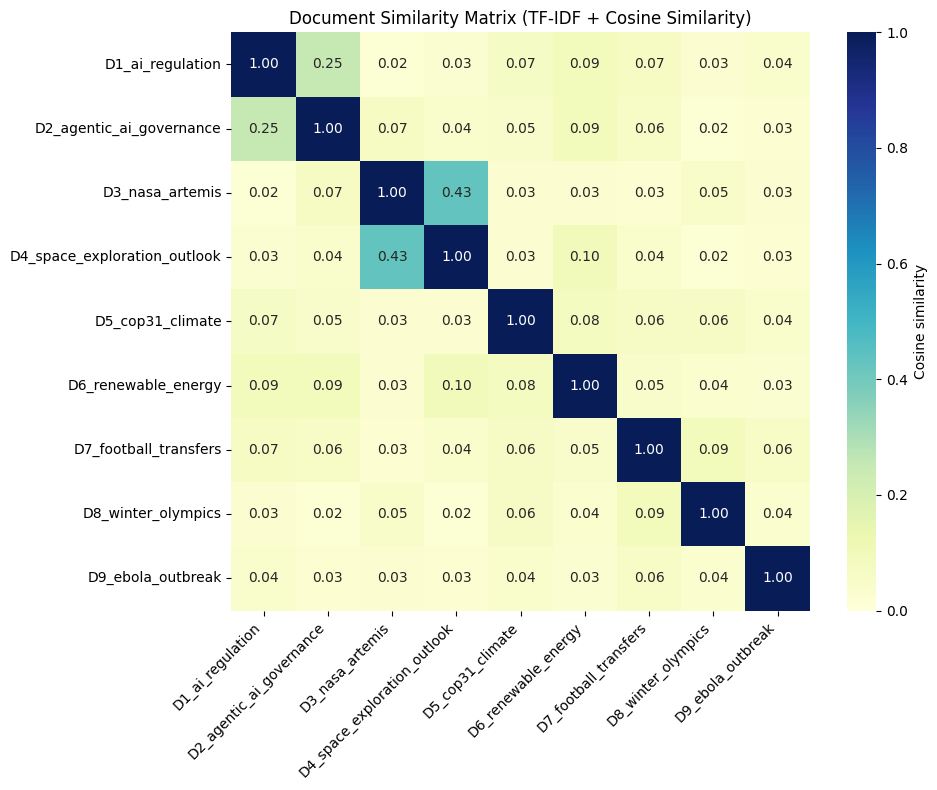

In [13]:
short_labels = [name.replace(".txt", "").replace("doc", "D") for name in doc_names]

plt.figure(figsize=(10, 8))
sns.heatmap(sim_df.values, xticklabels=short_labels, yticklabels=short_labels,
            annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, square=True,
            cbar_kws={"label": "Cosine similarity"})
plt.title("Document Similarity Matrix (TF-IDF + Cosine Similarity)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 14: Average similarity bar chart

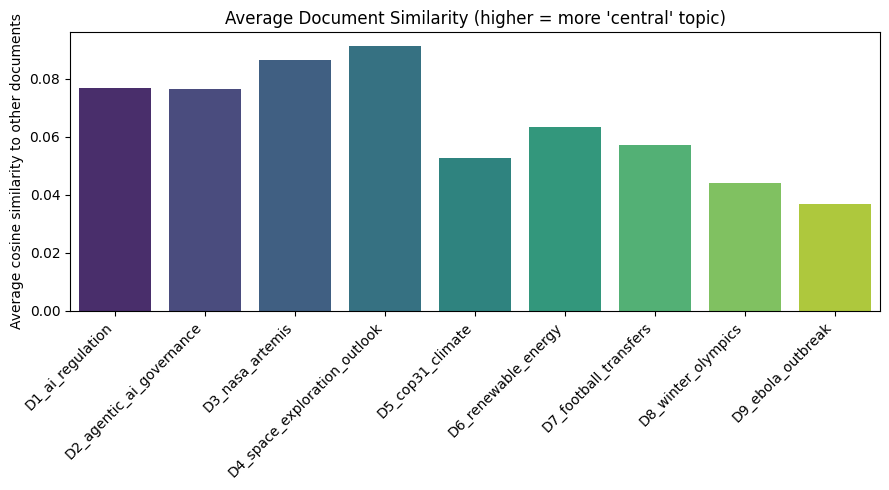

In [14]:
avg_sim = (sim_matrix.sum(axis=1) - 1) / (n - 1)  # exclude self-similarity

plt.figure(figsize=(9, 5))
sns.barplot(x=short_labels, y=avg_sim, hue=short_labels, palette="viridis", legend=False)
plt.ylabel("Average cosine similarity to other documents")
plt.title("Average Document Similarity (higher = more 'central' topic)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()